# Stuttering Detection: Tree-Based Ensemble Analysis
**Course**: CS204T (Artificial Intelligence)  
**Team**: 18  
**Focus**: Single Decision Trees vs. Random Forests

---

## Step 1: Initialization

In [1]:
import os
import joblib
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.extractors import WavLMExtractor
from src.data import DataManager
from src.models import DecisionTreeModel, RandomForestModel
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, f1_score

# Dataset Configuration
AUDIO_DIR = "Stuttering Events in Podcasts Dataset/clips/stuttering-clips/clips"
CSV_PATHS = [
    "Stuttering Events in Podcasts Dataset/SEP-28k_labels.csv",
    "Stuttering Events in Podcasts Dataset/fluencybank_labels.csv"
]
FEATURE_DIR = "data/features"
fluent_dir = os.path.join(FEATURE_DIR, "fluent")
disfluent_dir = os.path.join(FEATURE_DIR, "disfluent")

/home/anshuman139/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
RANDOM_SEED=42

## Step 2 (Optional): Operational Mode for Data Extraction
* `SKIP_EXTRACTION`: Uses features already on disk (Default).
* `FORCE_EXTRACT`: Analyzes raw audio for new files (Resumable).
* `CLEAN_START`: Wipes the database and re-extracts from zero.

In [2]:
# Operational Flags
SKIP_EXTRACTION = True
FORCE_EXTRACT = False
CLEAN_START = False
SAMPLE_LIMIT = None
STRICT_LABELS = True # Set to True to filter out ambiguous samples (Score 1 & 2)
NUM_CLIPS_TO_EXTRACT = 1000

if CLEAN_START:
    if os.path.exists(FEATURE_DIR):
        shutil.rmtree(FEATURE_DIR)
    print("[System] Clean start initiated. Wiped feature database.")

if not SKIP_EXTRACTION or CLEAN_START or FORCE_EXTRACT:
    extractor = WavLMExtractor("microsoft/wavlm-base")
    label_dict = DataManager.generate_label_dict(CSV_PATHS, filter_quality=True, strict=STRICT_LABELS)
    
    # Now using NATIVE Random Sampling logic for diversity
    extractor.extract_from_dir(
        AUDIO_DIR, 
        output_dir=FEATURE_DIR, 
        label_dict=label_dict, 
        limit=NUM_CLIPS_TO_EXTRACT, 
        random_sample=True
    )
else:
    print("[System] Skipping extraction. Using existing data on disk.")

[System] Skipping extraction. Using existing data on disk.


## Step 3: Data Preparation

In [3]:
label_dict = DataManager.generate_label_dict(CSV_PATHS, filter_quality=True, strict=STRICT_LABELS)
manager = DataManager(None, None)

# Smart Load: Using Keyword Arguments
X, y = manager.load_from_folders(fluent_dir=fluent_dir, disfluent_dir=disfluent_dir, limit=SAMPLE_LIMIT, label_dict=label_dict)
X_train, X_val, X_test, y_train, y_val, y_test = manager.get_splits(test_size=0.15, val_size=0.15)
# Preprocessing Engine: Enforcing fit=False on Val/Test
X_train_bal, y_train_bal = manager.balance_data(X_train, y_train, strategy="oversample")
X_train_final = manager.preprocess(X_train_bal, method="standard", fit=True)
X_val_final = manager.preprocess(X_val, method="standard", fit=False)
X_test_final = manager.preprocess(X_test, method="standard", fit=False)

[DataManager] Quality Filter: Removed 3938 low-quality samples.
[DataManager] Strict Filter: Kept 16109 high-agreement samples (Removed 12274 ambiguous samples).
[DataManager] Strict Filtering: Kept 14452 high-agreement samples (Discarded 11361 ambiguous samples).


## Step 4: Model 1 - Decision Tree

In [4]:
dt_model = DecisionTreeModel("Decision_Tree_Baseline", max_depth=10)
dt_model.train(X_train_final, y_train_bal)

print("\n--- Evaluation on Unseen Test Set ---")
dt_model.evaluate(X_test_final, y_test)

[Model: Decision_Tree_Baseline] Initialized.
[Decision_Tree_Baseline] Building Logic Tree (Max Depth: 10)...

--- Evaluation on Unseen Test Set ---

--- Evaluation: Decision_Tree_Baseline ---
Accuracy: 0.6720
Precision: 0.6615
Recall: 0.5920
F1: 0.6248

Confusion Matrix (Binary):
               Predicted: Fluent(0)  Predicted: Stutter(1)
True: Fluent(0)      865             303            
True: Stutter(1)     408             592            


{'accuracy': 0.6720479704797048,
 'precision': 0.6614525139664804,
 'recall': 0.592,
 'f1': 0.6248021108179419,
 'confusion_matrix': array([[865, 303],
        [408, 592]])}

## Step 5: Model 2 - Random Forest (Ensemble)

In [5]:
rf_model = RandomForestModel("Random_Forest_Ensemble", n_estimators=100, max_depth=15)
rf_model.train(X_train_final, y_train_bal)

print("\n--- Evaluation on Unseen Test Set ---")
rf_model.evaluate(X_test_final, y_test)

[Model: Random_Forest_Ensemble] Initialized.
[Random_Forest_Ensemble] Planting 100 Trees (Max Depth: 15)...

--- Evaluation on Unseen Test Set ---

--- Evaluation: Random_Forest_Ensemble ---
Accuracy: 0.7537
Precision: 0.8192
Recall: 0.5980
F1: 0.6913

Confusion Matrix (Binary):
               Predicted: Fluent(0)  Predicted: Stutter(1)
True: Fluent(0)      1036            132            
True: Stutter(1)     402             598            


{'accuracy': 0.753690036900369,
 'precision': 0.8191780821917808,
 'recall': 0.598,
 'f1': 0.6913294797687861,
 'confusion_matrix': array([[1036,  132],
        [ 402,  598]])}

# Part 2: Hyperparameter Optimization
---

In [6]:
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Prepare Cross-Validation Split (Combining Train + Val)
X_train_val = np.vstack((X_train_final, manager.preprocess(X_val, method="standard", fit=False)))
y_train_val = np.hstack((y_train_bal, y_val))

# -1 for training indices, 0 for validation indices
split_indices = np.hstack((
    -1 * np.ones(len(X_train_final)),
    idx_val := np.zeros(len(X_val))
))
ps = PredefinedSplit(test_fold=split_indices)

print(f"Tuning setup ready. Total samples: {len(X_train_val)}")

Tuning setup ready. Total samples: 13064


In [7]:
print("--- Tuning Decision Tree ---")
dt_params = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params, cv=ps, scoring='accuracy', n_jobs=-1)
dt_grid.fit(X_train_val, y_train_val)

# Export DT benchmarks
pd.DataFrame(dt_grid.cv_results_).to_csv("reports/tree_hypertuning_benchmarks_dt.csv", index=False)

print(f"Best DT Params: {dt_grid.best_params_}")
print(f"Best DT Val Accuracy: {dt_grid.best_score_:.4f}")


--- Tuning Decision Tree ---
Best DT Params: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 2}
Best DT Val Accuracy: 0.6808


In [8]:
print("--- Tuning Random Forest ---")
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 15, 20, None],
    'max_features': ['sqrt', 'log2', None]
}

rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=ps, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train_val, y_train_val)

# Export RF benchmarks
pd.DataFrame(rf_grid.cv_results_).to_csv("reports/tree_hypertuning_benchmarks_rf.csv", index=False)

print(f"Best RF Params: {rf_grid.best_params_}")
print(f"Best RF Val Accuracy: {rf_grid.best_score_:.4f}")


--- Tuning Random Forest ---
Best RF Params: {'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 200}
Best RF Val Accuracy: 0.7643



--- Final Optimized Random Forest Evaluation ---
              precision    recall  f1-score   support

         0.0       0.74      0.86      0.79      1168
         1.0       0.80      0.64      0.71      1000

    accuracy                           0.76      2168
   macro avg       0.77      0.75      0.75      2168
weighted avg       0.77      0.76      0.76      2168


[HARVEST] Tree Final Accuracy: 0.7592
[HARVEST] Tree Final F1: 0.7094


<Figure size 600x500 with 0 Axes>

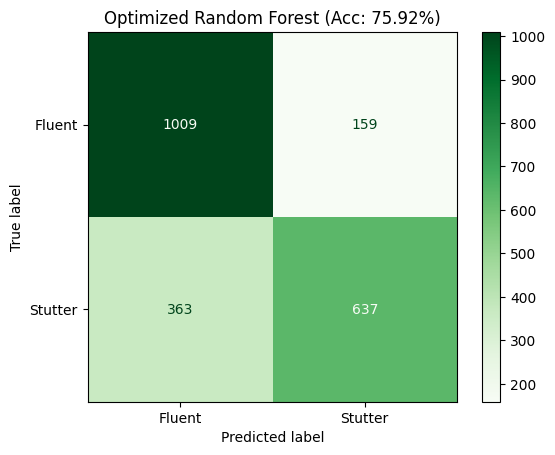

In [9]:
best_rf = rf_grid.best_estimator_
y_pred = best_rf.predict(X_test_final)

print("\n--- Final Optimized Random Forest Evaluation ---")
print(classification_report(y_test, y_pred))

# HARVEST FOR LEADERBOARD
tree_final_accuracy = accuracy_score(y_test, y_pred)
tree_final_f1 = f1_score(y_test, y_pred)
print(f"\n[HARVEST] Tree Final Accuracy: {tree_final_accuracy:.4f}")
print(f"[HARVEST] Tree Final F1: {tree_final_f1:.4f}")

plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(best_rf, X_test_final, y_test, cmap='Greens', display_labels=['Fluent', 'Stutter'])
plt.title(f"Optimized Random Forest (Acc: {tree_final_accuracy*100:.2f}%)")
plt.show()


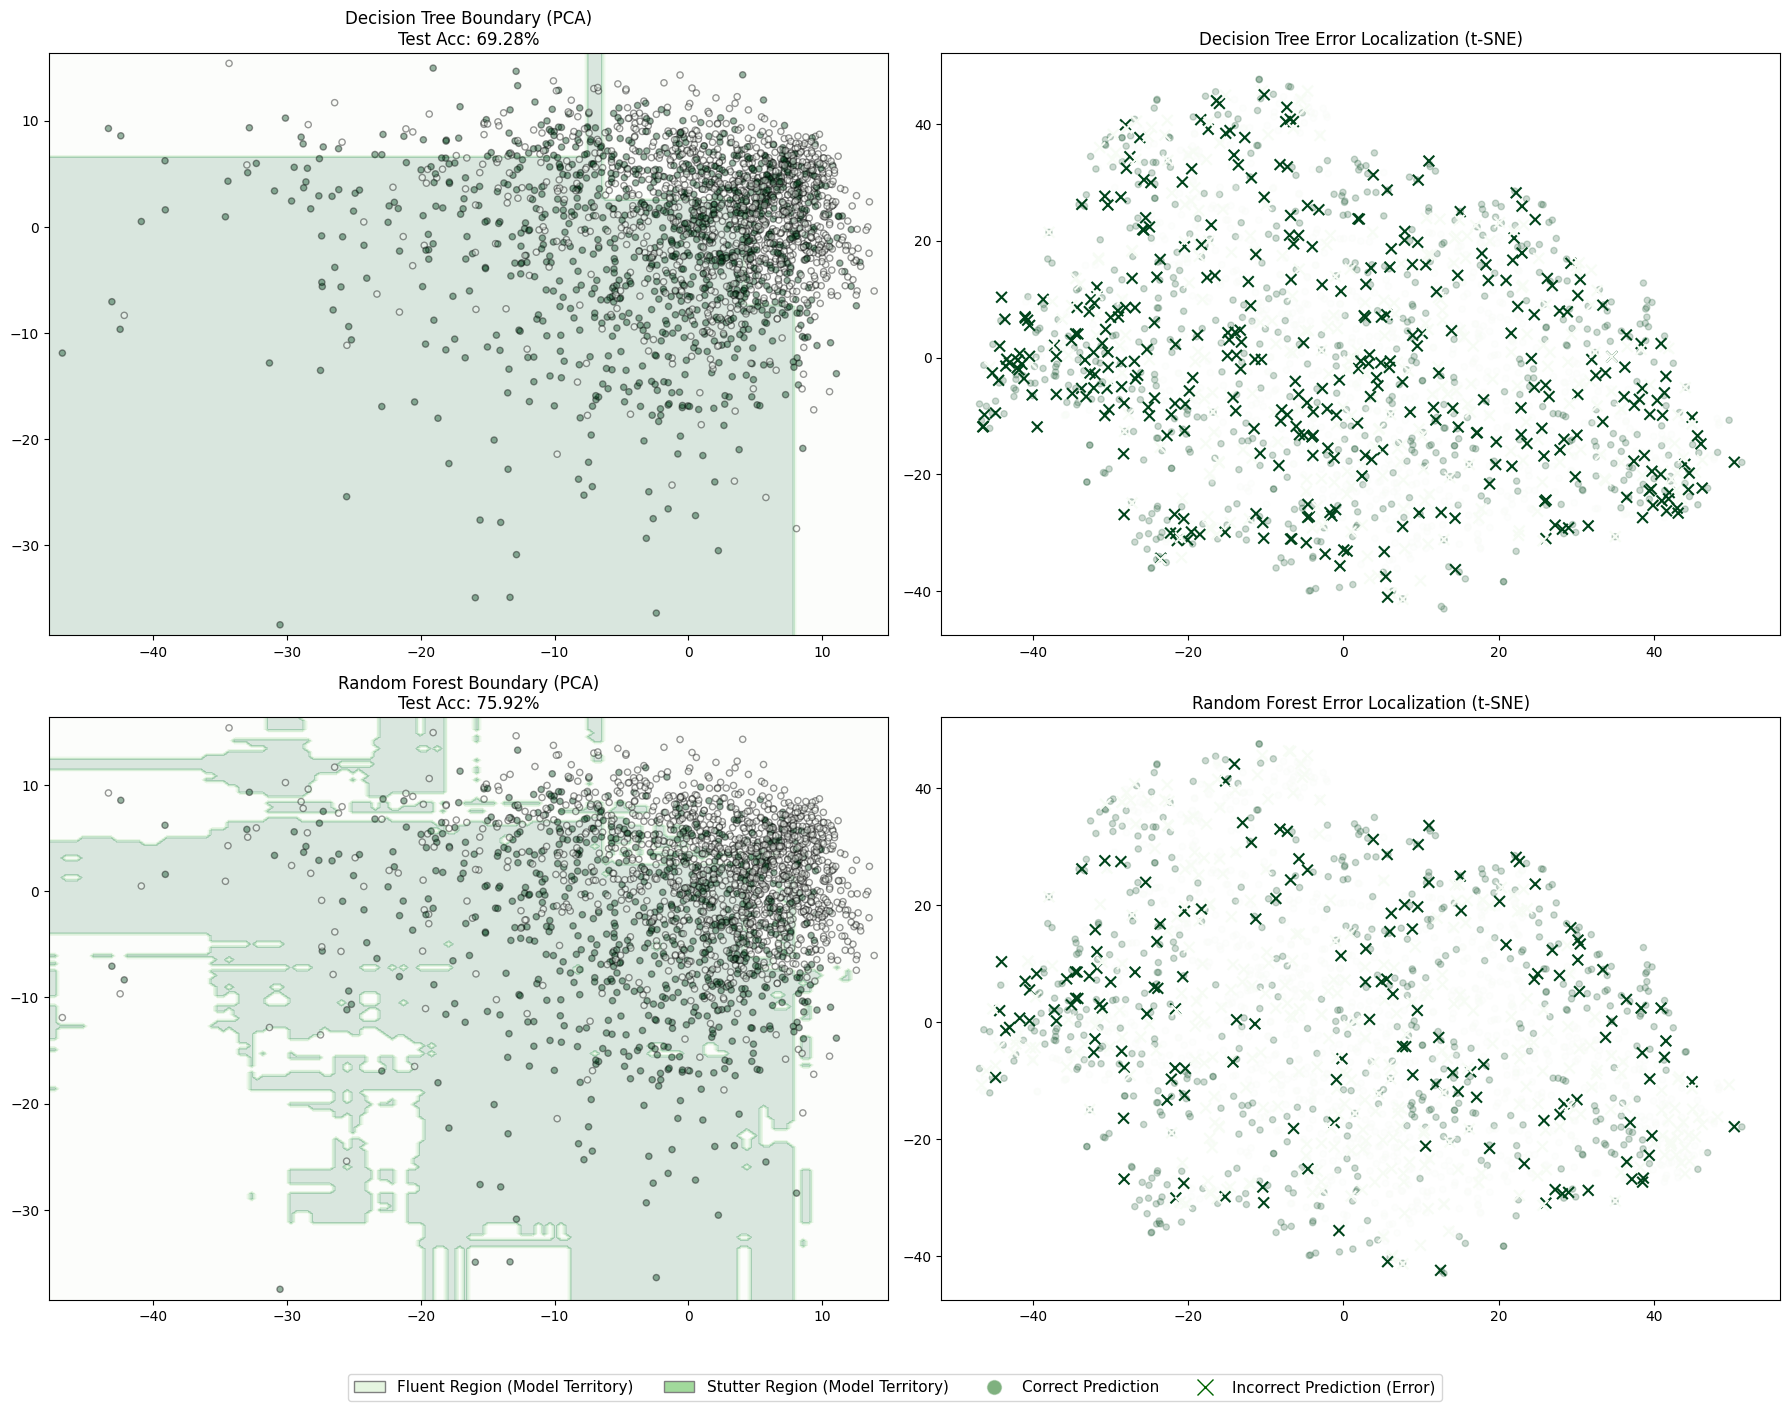

In [17]:
# --- STEP 17: DUAL-MANIFOLD DIAGNOSTICS & ERROR LOCALIZATION ---
from sklearn.manifold import TSNE
import scipy.ndimage as ndimage
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# 1. Compute Manifolds
pca_vis = PCA(n_components=2, random_state=RANDOM_SEED)
X_test_pca = pca_vis.fit_transform(X_test_final)
X_train_pca = pca_vis.transform(X_train_final)

VIS_LIMIT = 2000
tsne = TSNE(n_components=2, perplexity=30, init='pca', random_state=RANDOM_SEED, n_jobs=-1)
X_tsne = tsne.fit_transform(X_test_final[:VIS_LIMIT])

# 2. Re-train 2D Proxies for PCA Visualization
dt_params = dt_grid.best_params_ if 'dt_grid' in globals() else {'max_depth': 10}
dt_2d = DecisionTreeClassifier(**dt_params, random_state=RANDOM_SEED).fit(X_train_pca, y_train_bal)
rf_2d = RandomForestClassifier(**rf_grid.best_params_, random_state=RANDOM_SEED).fit(X_train_pca, y_train_bal)

# 3. Setup Mesh Grid for PCA Surfaces
res = 150 
x_min, x_max = X_test_pca[:, 0].min() - 1, X_test_pca[:, 0].max() + 1
y_min, y_max = X_test_pca[:, 1].min() - 1, X_test_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, res), np.linspace(y_min, y_max, res))

Z_dt = dt_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
Z_rf = rf_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# --- ROW 1: DECISION TREE ---
axes[0,0].contourf(xx, yy, Z_dt, alpha=0.15, cmap='Greens')
axes[0,0].scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_pred_dt, cmap='Greens', alpha=0.4, edgecolors='k', s=20)
axes[0,0].set_title(f"Decision Tree Boundary (PCA)\nTest Acc: {accuracy_score(y_test, y_pred_dt):.2%}")

correct_dt = (y_test[:VIS_LIMIT] == y_pred_dt[:VIS_LIMIT])
axes[0,1].scatter(X_tsne[correct_dt, 0], X_tsne[correct_dt, 1], c=y_pred_dt[:VIS_LIMIT][correct_dt], cmap='Greens', alpha=0.2, s=20)
axes[0,1].scatter(X_tsne[~correct_dt, 0], X_tsne[~correct_dt, 1], c=y_pred_dt[:VIS_LIMIT][~correct_dt], cmap='Greens', alpha=1.0, s=60, marker='x')
axes[0,1].set_title("Decision Tree Error Localization (t-SNE)")

# --- ROW 2: RANDOM FOREST ---
axes[1,0].contourf(xx, yy, Z_rf, alpha=0.15, cmap='Greens')
axes[1,0].scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_pred_rf, cmap='Greens', alpha=0.4, edgecolors='k', s=20)
axes[1,0].set_title(f"Random Forest Boundary (PCA)\nTest Acc: {accuracy_score(y_test, y_pred_rf):.2%}")

correct_rf = (y_test[:VIS_LIMIT] == y_pred_rf[:VIS_LIMIT])
axes[1,1].scatter(X_tsne[correct_rf, 0], X_tsne[correct_rf, 1], c=y_pred_rf[:VIS_LIMIT][correct_rf], cmap='Greens', alpha=0.2, s=20)
axes[1,1].scatter(X_tsne[~correct_rf, 0], X_tsne[~correct_rf, 1], c=y_pred_rf[:VIS_LIMIT][~correct_rf], cmap='Greens', alpha=1.0, s=60, marker='x')
axes[1,1].set_title("Random Forest Error Localization (t-SNE)")

# --- UNIFIED LEGEND ---
legend_elements_17 = [
    # The Background Regions (The "Curve" Territories)
    Patch(facecolor='#e5f5e0', edgecolor='gray', label='Fluent Region (Model Territory)'),
    Patch(facecolor='#a1d99b', edgecolor='gray', label='Stutter Region (Model Territory)'),
    
    # The Data Points
    Line2D([0], [0], marker='o', color='w', label='Correct Prediction', markerfacecolor='darkgreen', markersize=11, alpha=0.5),
    Line2D([0], [0], marker='x', color='darkgreen', label='Incorrect Prediction (Error)', markersize=11, linestyle='None')
]
fig.legend(handles=legend_elements_17, loc='lower center', ncol=4, frameon=True, fontsize=11, bbox_to_anchor=(0.5, -0.01))

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()


In [11]:

# Ensure models directory exists
os.makedirs("models", exist_ok=True)

# Save the best Random Forest model
joblib.dump(best_rf, "models/random_forest_best.joblib")
print("[System] Random Forest Model saved to models/random_forest_best.joblib")


[System] Random Forest Model saved to models/random_forest_best.joblib


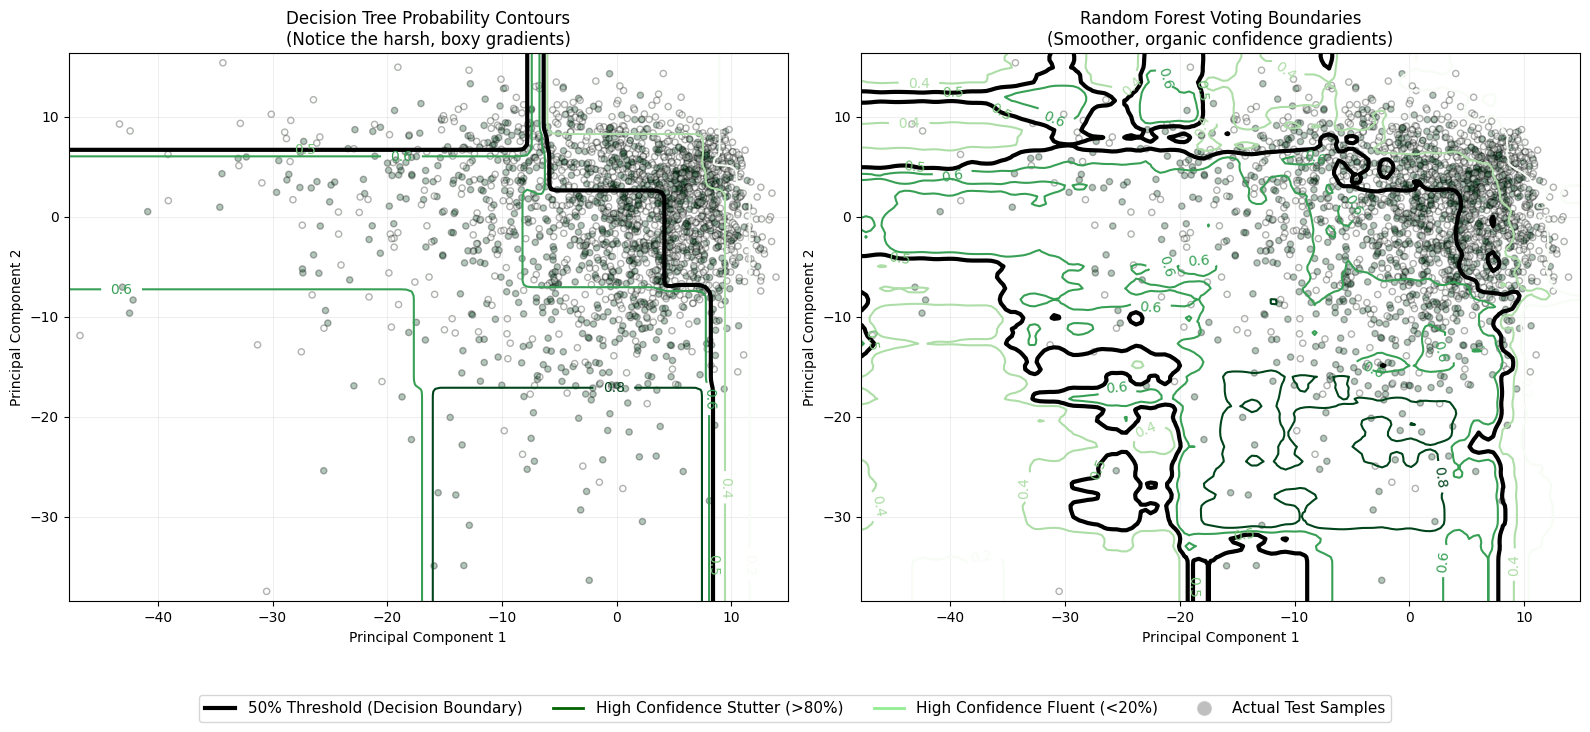

In [18]:
# --- STEP 18: ENSEMBLE VOTING CONFIDENCE (PROBABILITY CONTOURS) ---
import scipy.ndimage as ndimage
from matplotlib.lines import Line2D

# 1. Extract Probabilities from the proxy models
Z_dt_prob = dt_2d.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)
Z_rf_prob = rf_2d.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)

# 2. Apply Gaussian smoothing for visualization aesthetics
Z_dt_smooth = ndimage.gaussian_filter(Z_dt_prob, sigma=1.0)
Z_rf_smooth = ndimage.gaussian_filter(Z_rf_prob, sigma=1.0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# --- PLOT A: Decision Tree Contours ---
contours_dt = ax1.contour(xx, yy, Z_dt_smooth, levels=[0.2, 0.4, 0.5, 0.6, 0.8], cmap='Greens', linewidths=1.5)
ax1.clabel(contours_dt, inline=True, fontsize=10, fmt='%.1f')
ax1.contour(xx, yy, Z_dt_smooth, levels=[0.5], colors='black', linewidths=3)
ax1.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap='Greens', edgecolors='k', alpha=0.3, s=20)
ax1.set_title("Decision Tree Probability Contours\n(Notice the harsh, boxy gradients)")
ax1.set_xlabel("Principal Component 1")
ax1.set_ylabel("Principal Component 2")
ax1.grid(alpha=0.2)

# --- PLOT B: Random Forest Contours ---
contours_rf = ax2.contour(xx, yy, Z_rf_smooth, levels=[0.2, 0.4, 0.5, 0.6, 0.8], cmap='Greens', linewidths=1.5)
ax2.clabel(contours_rf, inline=True, fontsize=10, fmt='%.1f')
ax2.contour(xx, yy, Z_rf_smooth, levels=[0.5], colors='black', linewidths=3)
ax2.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap='Greens', edgecolors='k', alpha=0.3, s=20)
ax2.set_title("Random Forest Voting Boundaries\n(Smoother, organic confidence gradients)")
ax2.set_xlabel("Principal Component 1")
ax2.set_ylabel("Principal Component 2")
ax2.grid(alpha=0.2)

# --- UNIFIED LEGEND ---
legend_elements_18 = [
    # The Decision Boundary
    Line2D([0], [0], color='black', lw=3, label='50% Threshold (Decision Boundary)'),
    # The Contour Colors
    Line2D([0], [0], color='darkgreen', lw=2, label='High Confidence Stutter (>80%)'),
    Line2D([0], [0], color='lightgreen', lw=2, label='High Confidence Fluent (<20%)'),
    # Data points
    Line2D([0], [0], marker='o', color='w', label='Actual Test Samples', markerfacecolor='gray', markersize=11, alpha=0.5)
]
fig.legend(handles=legend_elements_18, loc='lower center', ncol=4, frameon=True, fontsize=11, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()
